# CSE5CV Assignment 2

In [ ]:
# Type your student ID number as an integer here.

STUDENT_ID = 21435050

# Table of content:

1.   Import modules and video.
2.   Task 2.
3.   Task 3.

  3.1   Object tracking IoU to the detections.

  3.2   Improve tracking results.

**Task 1 video named 21435050.mp4**

# 1. Import modules and video

In [2]:
import copy
import math

import numpy as np
import cv2
import matplotlib.pyplot as plt
import scipy
import scipy.optimize
import torch
import torchvision
import torchvision.transforms.functional as tvtf

from google.colab import drive

Connect Google Colab to Google Drive.

In [9]:
drive.mount('/content/drive', force_remount=True)
notebook_path = '/content/drive/MyDrive/21435050_Assignment_2.ipynb'
%cd /content/drive/MyDrive

Mounted at /content/drive
/content/drive/MyDrive


Preview the first frame from video

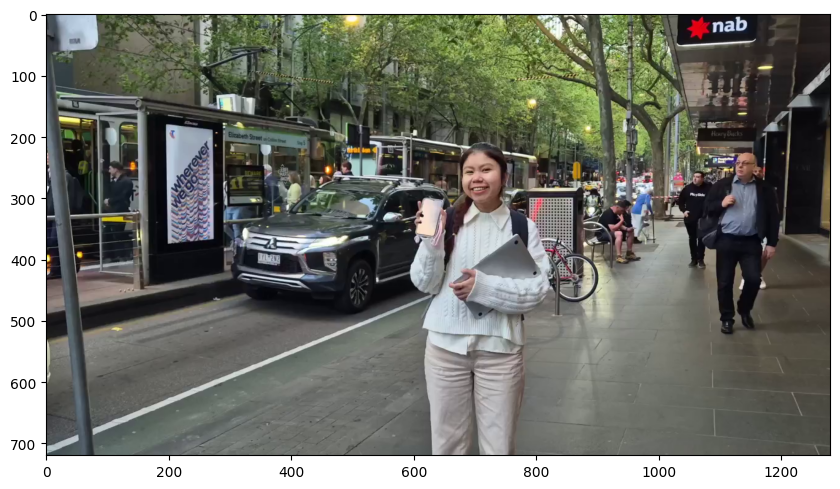

In [ ]:
filename = '/content/21435050.mp4'

vid = cv2.VideoCapture(filename)
_, img = vid.read()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(10, 5))
ax = plt.subplot(1, 1, 1)
ax.imshow(img)
fig.tight_layout()

Use Mask R-CNN to detect bounding boxes, object class labels, and confidence scores for each frame of the video.

In [ ]:
def preprocess_image(image):
    image = tvtf.to_tensor(image)
    image = image.unsqueeze(dim=0)
    return image

maskrcnn = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
maskrcnn.eval()
if torch.cuda.is_available():
    maskrcnn.cuda()

# Go to the start of the video
vid.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Record how long the video is (in frames)
vid_length = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))

# For each frame, read it, give it to maskrcnn and record the detections
all_boxes = []
all_labels = []
all_scores = []
for i in range(vid_length):
    _, img = vid.read()
    if img is None:
        break
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    with torch.no_grad():
        input_image = preprocess_image(img)
        if torch.cuda.is_available():
            input_image = input_image.cuda()
        result = maskrcnn(input_image)[0]

    all_boxes.append(result['boxes'].detach().cpu().numpy())
    all_labels.append(result['labels'].detach().cpu().numpy())
    all_scores.append(result['scores'].detach().cpu().numpy())
    if i % 20 == 0:
        print(f'{i+1:0d}/{vid_length}')

torch.save(all_boxes, 'all_boxes.pt')
torch.save(all_labels, 'all_labels.pt')
torch.save(all_scores, 'all_scores.pt')

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:02<00:00, 65.7MB/s]


1/610
21/610
41/610
61/610
81/610
101/610
121/610
141/610
161/610
181/610
201/610
221/610
241/610
261/610
281/610
301/610
321/610
341/610
361/610
381/610
401/610
421/610
441/610
461/610
481/610
501/610
521/610
541/610
561/610
581/610
601/610


Load the detections such as `all_boxes.pt`, `all_labels.pt`, and `all_scores.pt` from Google Drive

In [ ]:
all_boxes = torch.load('all_boxes.pt')
all_labels = torch.load('all_labels.pt')
all_scores = torch.load('all_scores.pt')

vid_length = len(all_boxes)

print(f'Loaded detections for {vid_length} video frames')

Loaded detections for 610 video frames


<ipython-input-5-6aa52058e509>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_boxes = torch.load('all_boxes.pt')
<ipython-input-5-6aa52058e509>:2: FutureWarning: You a

# 2. Task 2

In [ ]:
# Preprocesses the input image and moves it to the correct device
def preprocess_image(image, device):
    image = tvtf.to_tensor(image)
    image = image.unsqueeze(dim=0).to(device)
    return image

# Set up the object classes
object_classes = {
    1: 'person',
    2: 'bicycle',
    3: 'car',
    4: 'motorcycle',
    73: 'laptop',
    77: 'cellphone'
}

# Set up different confidence score thresholds for each class
class_threshold = {
    1: 0.5,  # person
    2: 0.5,  # bicycle
    3: 0.4,  # car
    4: 0.4,  # motorcycle
    73: 0.8, # laptop
    77: 0.8  # cellphone
}

def get_detections(maskrcnn, vid, device):
    ''' Runs maskrcnn over all frames in vid, storing the detections '''

    vid_length = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))

    initial_frame = int(vid.get(cv2.CAP_PROP_POS_FRAMES))

    # Set the video to frame 0
    vid.set(cv2.CAP_PROP_POS_FRAMES, 0)

    det = []  # List to store detections
    for i in range(vid_length):
        ret, img = vid.read()
        if not ret:
            break

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Preprocess image and move it to the device
        img_tensor = preprocess_image(img, device)

        with torch.no_grad():
            result = maskrcnn(img_tensor)[0]

        frame_detections = []

        for class_index in object_classes.keys():
            # Apply mask for the specific object class
            class_mask = result["labels"] == class_index
            # Apply mask for the confidence score threshold
            score_mask = result["scores"] > class_threshold[class_index]
            mask = class_mask & score_mask

            # Extract the bounding boxes for the detections that meet both conditions
            boxes = result["boxes"][mask].detach().cpu().numpy()

            # Add the detections to the list with the class information
            for box in boxes:
                frame_detections.append({
                    'box': box,
                    'class': object_classes[class_index],
                    'score': result["scores"][mask].detach().cpu().numpy()
                })

        det.append(frame_detections)
        print(f'Processed frame {i+1}/{vid_length}')

    return det

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize pre-trained Mask R-CNN model and transfer to device
maskrcnn = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="COCO_V1")
maskrcnn = maskrcnn.to(device)
maskrcnn.eval()

# Open video
vid = cv2.VideoCapture('./21435050.mp4')

# Run the detection function with class-specific thresholds
all_detections = get_detections(maskrcnn, vid, device)

# Save detections to a file
torch.save(all_detections, './21435050-det.th')

Processed frame 1/610
Processed frame 2/610
Processed frame 3/610
Processed frame 4/610
Processed frame 5/610
Processed frame 6/610
Processed frame 7/610
Processed frame 8/610
Processed frame 9/610
Processed frame 10/610
Processed frame 11/610
Processed frame 12/610
Processed frame 13/610
Processed frame 14/610
Processed frame 15/610
Processed frame 16/610
Processed frame 17/610
Processed frame 18/610
Processed frame 19/610
Processed frame 20/610
Processed frame 21/610
Processed frame 22/610
Processed frame 23/610
Processed frame 24/610
Processed frame 25/610
Processed frame 26/610
Processed frame 27/610
Processed frame 28/610
Processed frame 29/610
Processed frame 30/610
Processed frame 31/610
Processed frame 32/610
Processed frame 33/610
Processed frame 34/610
Processed frame 35/610
Processed frame 36/610
Processed frame 37/610
Processed frame 38/610
Processed frame 39/610
Processed frame 40/610
Processed frame 41/610
Processed frame 42/610
Processed frame 43/610
Processed frame 44/6

In [ ]:
all_detections = torch.load('./21435050-det.th')

<ipython-input-8-8043b1d6b178>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_detections = torch.load('./21435050-det.th')


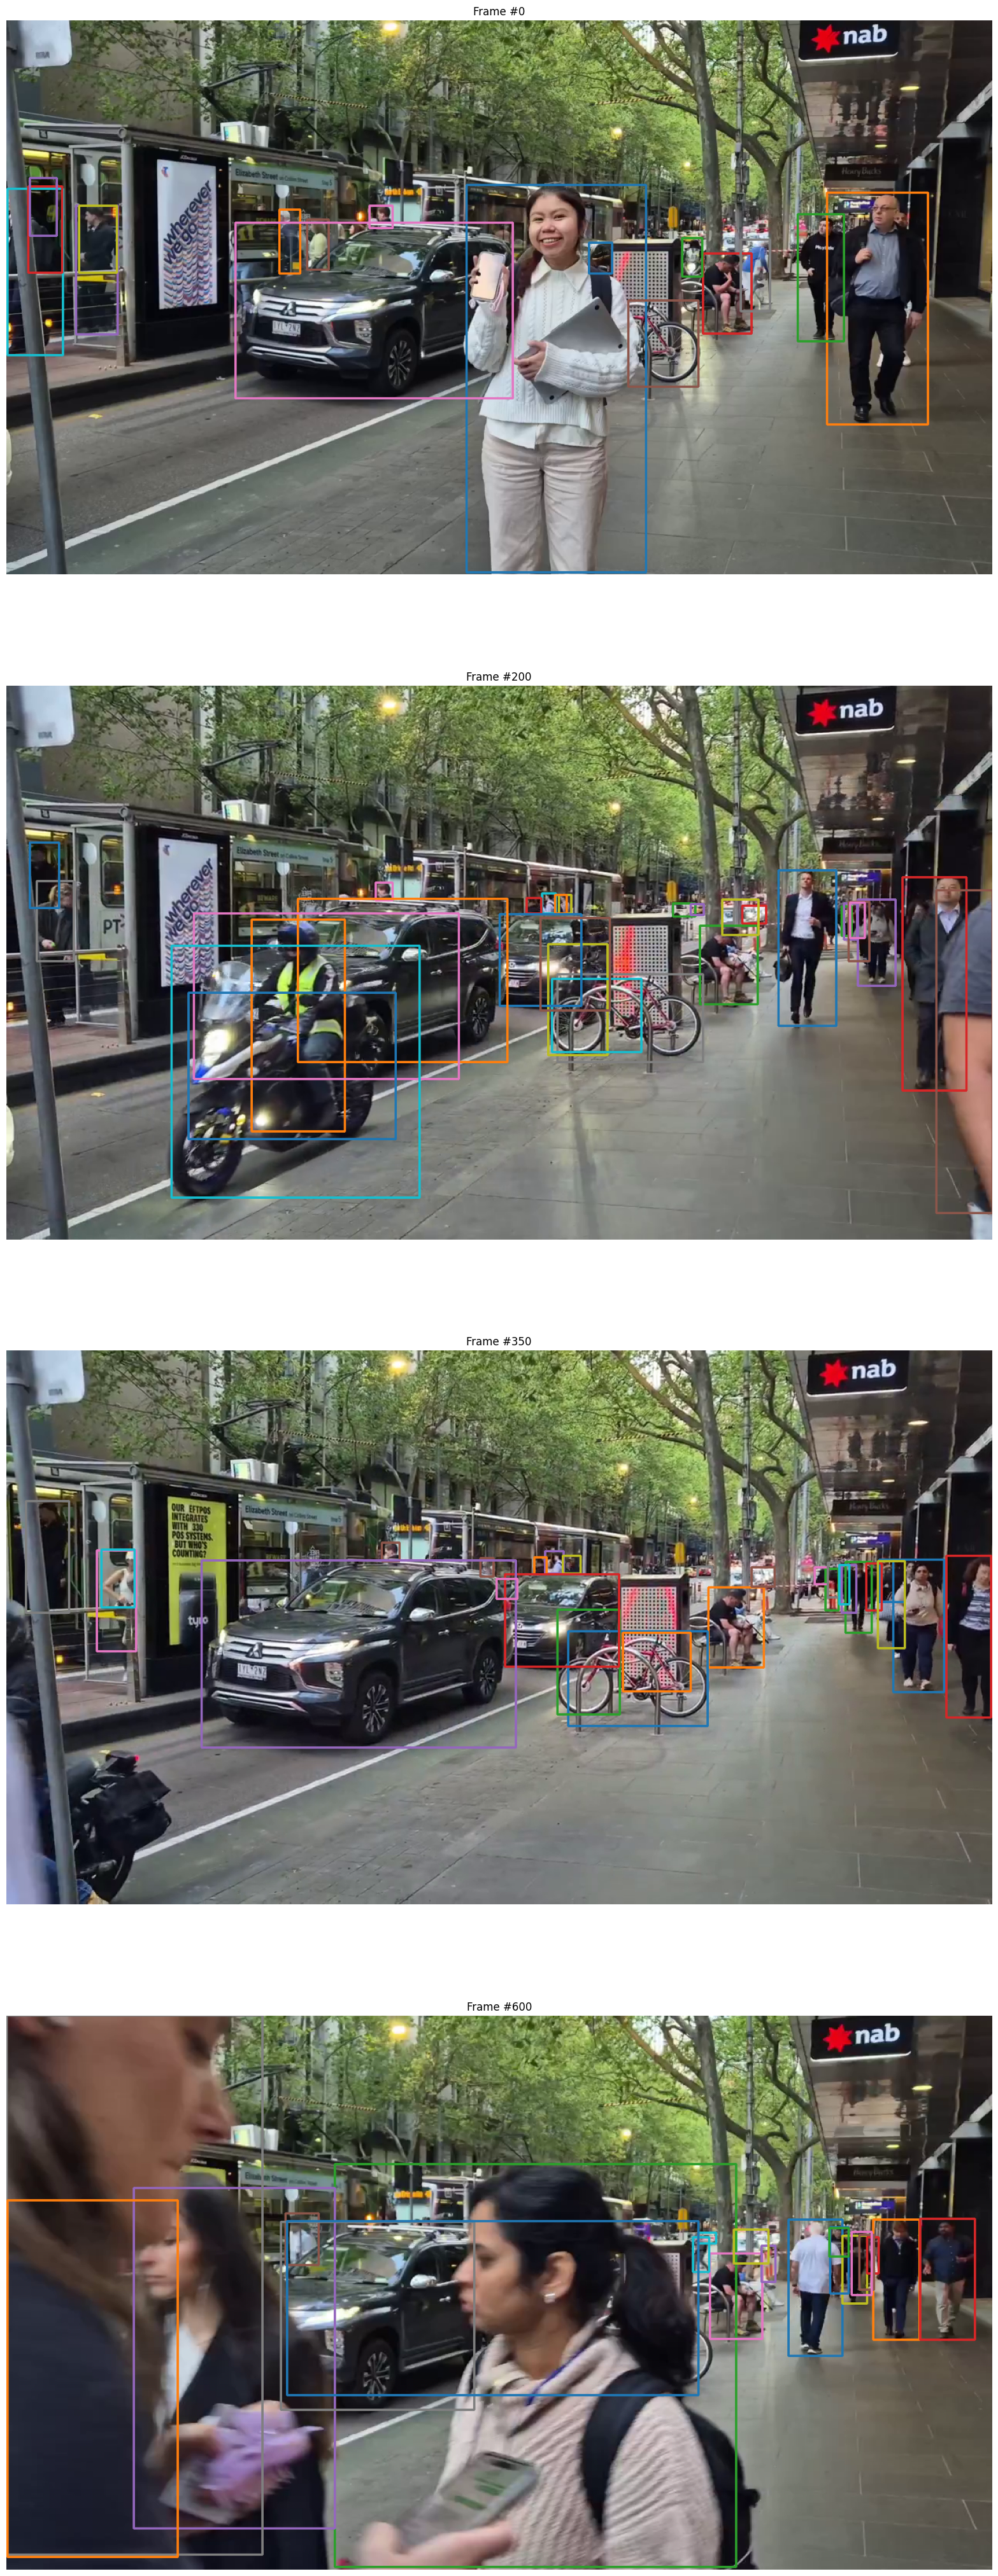

In [ ]:
COLOURS = [
    tuple(int(colour_hex.strip('#')[i:i+2], 16) for i in (0, 2, 4))
    for colour_hex in plt.rcParams['axes.prop_cycle'].by_key()['color']
]

def draw_detections(img, det, colours=COLOURS):
    for i, detection in enumerate(det):
        tlx, tly, brx, bry = detection['box']  # Extract the bounding box
        i %= len(colours)
        cv2.rectangle(img, (int(tlx), int(tly)), (int(brx), int(bry)), color=colours[i], thickness=2)

# Open video with cv2.VideoCapture
vid = cv2.VideoCapture('./21435050.mp4')

frame_numbers = [0, 200, 350, 600]
n_rows = len(frame_numbers)

fig, axes = plt.subplots(n_rows, 1, figsize=(22, 13 * n_rows))
for idx, fr_num in enumerate(frame_numbers):
    # Set vid to frame fr_num
    vid.set(cv2.CAP_PROP_POS_FRAMES, fr_num)

    # Read a frame
    _, img = vid.read()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get detections for frame fr_num out of all_detections
    det = all_detections[fr_num]

    # Extract just the boxes from each detection dictionary and convert to np.int32
    boxes = [d['box'] for d in det]  # Extract the bounding boxes
    boxes = np.array(boxes).astype(np.int32)  # Convert to np.int32

    # Draw detections on img
    draw_detections(img, det)

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f'Frame #{fr_num}')
plt.savefig('./detections.png')


# 3. Task 3

## 3.1 Object tracking IoU to the detections

In [ ]:
from collections import defaultdict

# Calculate IoU between two bounding boxes
def iou(a, b):
    x1, y1, x2, y2 = a
    x1_p, y1_p, x2_p, y2_p = b

    xi1 = max(x1, x1_p)
    yi1 = max(y1, y1_p)
    xi2 = min(x2, x2_p)
    yi2 = min(y2, y2_p)

    intersection = max(xi2 - xi1, 0) * max(yi2 - yi1, 0)

    area_a = (x2 - x1) * (y2 - y1)
    area_b = (x2_p - x1_p) * (y2_p - y1_p)

    union = area_a + area_b - intersection
    return intersection / union if union > 0 else 0

Track objects by object class separately using IoU

In [ ]:
class ObjectTracker:
    def __init__(self, iou_threshold=0.3, max_lost=20):
        self.iou_threshold = iou_threshold
        self.max_lost = max_lost
        self.tracks = defaultdict(lambda: [])  # Each object class will have its own track list
        self.track_id_count = 0  # Unique ID for each track
        self.lost_tracks = {}  # Keep track of lost track counts

    def update_tracks(self, detections, object_classes):
        active_tracks = self.tracks[object_classes]
        updated_tracks = []

        for det in detections:
            box = det['box']
            found_match = False

            for track in active_tracks:
                track_box = track[-1]['box']
                if iou(box, track_box) > self.iou_threshold:
                    track.append(det)
                    updated_tracks.append(track)
                    found_match = True
                    break

            if not found_match:
                self.track_id_count += 1
                new_track = [{'id': self.track_id_count, 'box': box}]
                updated_tracks.append(new_track)

        # Remove old tracks not updated recently
        self.tracks[object_classes] = [t for t in updated_tracks if len(t) <= self.max_lost]

    def draw_tracks(self, img, object_classes):
        active_tracks = self.tracks[object_classes]
        for track in active_tracks:
            box = track[-1]['box']
            track_id = track[0]['id']
            tlx, tly, brx, bry = [int(c) for c in box]
            cv2.rectangle(img, (tlx, tly), (brx, bry), (0, 255, 0), 2)
            cv2.putText(img, f'{object_classes} ID: {track_id}', (tlx, tly-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

Main tracking loop to process the video

In [ ]:
def run_tracking(vid, all_detections, output_file="task3-1.mp4"):
    vid_width = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
    vid_height = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(vid.get(cv2.CAP_PROP_FPS))
    frame_count = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    vid_out = cv2.VideoWriter(output_file, fourcc, fps, (vid_width, vid_height))

    tracker = ObjectTracker(iou_threshold=0.5)

    for i in range(frame_count):
        ret, img = vid.read()
        if not ret:
            break

        detections = all_detections[i]

        for class_index in object_classes.keys():
            class_detections = [d for d in detections if d['class'] == object_classes[class_index]]
            tracker.update_tracks(class_detections, object_classes[class_index])
            tracker.draw_tracks(img, object_classes[class_index])

        vid_out.write(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    vid.release()
    vid_out.release()

# Open video file and run tracking
vid = cv2.VideoCapture('./21435050.mp4')
run_tracking(vid, all_detections)


Export video

In [ ]:
from google.colab import files
files.download('./task3-1.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3.2 Improve tracking result

In [ ]:
class ObjectTracker:
    def __init__(self, iou_threshold=0.5, max_lost=5):
        self.iou_threshold = iou_threshold
        self.max_lost = max_lost
        self.tracks = defaultdict(list)
        self.track_id_count = 0
        self.lost_tracks = defaultdict(int)

    def update_tracks(self, detections, object_classes):
        """Update object tracks with new detections for a specific class."""
        active_tracks = self.tracks[object_classes]
        updated_tracks = []
        unmatched_detections = []

        for det in detections:
            box = det['box']
            found_match = False

            # Try to match detection with existing tracks
            for track in active_tracks:
                track_box = track[-1]['box']
                if iou(box, track_box) > self.iou_threshold:
                    track.append(det)
                    updated_tracks.append(track)
                    found_match = True
                    break

            if not found_match:
                unmatched_detections.append(det)

        # Create new tracks for unmatched detections
        for det in unmatched_detections:
            self.track_id_count += 1
            new_track = [{'id': self.track_id_count, 'box': det['box']}]
            updated_tracks.append(new_track)

        # Keep tracks updated and reset lost track counter for active tracks
        self.tracks[object_classes] = updated_tracks

        # Manage lost tracks
        self.handle_lost_tracks(object_classes)

    def handle_lost_tracks(self, object_classes):
        """Remove tracks that have not been updated recently."""
        active_tracks = self.tracks[object_classes]
        self.tracks[object_classes] = [t for t in active_tracks if len(t) <= self.max_lost]

    def draw_tracks(self, img, object_classes):
        """Draw bounding boxes and track IDs on the image."""
        active_tracks = self.tracks[object_classes]
        for track in active_tracks:
            box = track[-1]['box']
            track_id = track[0]['id']
            tlx, tly, brx, bry = [int(c) for c in box]
            cv2.rectangle(img, (tlx, tly), (brx, bry), (0, 255, 0), 2)
            cv2.putText(img, f'{object_classes} ID: {track_id}', (tlx, tly - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

In [ ]:
def run_tracking(vid, all_detections, output_file="task3-2.mp4"):
    """Process video frame by frame and perform object tracking."""
    vid_width = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
    vid_height = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(vid.get(cv2.CAP_PROP_FPS))
    frame_count = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))

    # Video writer setup
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    vid_out = cv2.VideoWriter(output_file, fourcc, fps, (vid_width, vid_height))

    # Initialize object tracker with a specific IOU threshold
    tracker = ObjectTracker(iou_threshold=0.5)

    for i in range(frame_count):
        ret, img = vid.read()
        if not ret:
            break

        detections = all_detections[i]

        for class_index in object_classes.keys():
            class_detections = [d for d in detections if d['class'] == object_classes[class_index]]
            tracker.update_tracks(class_detections, object_classes[class_index])
            tracker.draw_tracks(img, object_classes[class_index])

        # Write the processed frame to output video
        vid_out.write(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    vid.release()
    vid_out.release()

vid = cv2.VideoCapture('./21435050.mp4')
run_tracking(vid, all_detections)

In [ ]:
from google.colab import files
files.download('./task3-2.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>